In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

## Importamos los datos

In [16]:
df = pd.read_csv("../data/stars_data.csv")

## EDA (Exploratory Data Analysis)

El dataset con el que vamos a trabajar tiene las siguientes características:

+ Entradas: 240

+ Columnas: 6
    + 4 Variables Numéricas

    + 2 Variables Categóricas con carácter ordinal

+ No existen Missing Values

In [17]:
# Información elemental de nuestro dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     240 non-null    int64  
 1   L               240 non-null    float64
 2   R               240 non-null    float64
 3   A_M             240 non-null    float64
 4   Color           240 non-null    object 
 5   Spectral_Class  240 non-null    object 
dtypes: float64(3), int64(1), object(2)
memory usage: 11.4+ KB


In [18]:
# Comprobamos si hay valores nulos en alguna fila
df.isna().sum()

Temperature       0
L                 0
R                 0
A_M               0
Color             0
Spectral_Class    0
dtype: int64

In [19]:
# Descriptivos de las variables numéricas
df.describe()

,Temperature,L,R,A_M
count,240.000000,240.000000,240.000000,240.000000
mean,10497.462500,107188.361635,237.157781,4.382396
std,9552.425037,179432.244940,517.155763,10.532512
min,1939.000000,0.000080,0.008400,-11.920000
25%,3344.250000,0.000865,0.102750,-6.232500
50%,5776.000000,0.070500,0.762500,8.313000
75%,15055.500000,198050.000000,42.750000,13.697500
max,40000.000000,849420.000000,1948.500000,20.060000


In [20]:
# Exploramos las categorías de las variables categóricas
for col in df.select_dtypes('object'):
    print(df[col].unique())
    print()
    print(df[col].value_counts())
    print()

['Red' 'Blue White' 'White' 'Yellowish White' 'Blue white'
 'Pale yellow orange' 'Blue' 'Blue-white' 'Whitish' 'yellow-white'
 'Orange' 'White-Yellow' 'white' 'yellowish' 'Yellowish' 'Orange-Red'
 'Blue-White']

Color
Red                   112
Blue                   56
Blue-white             26
Blue White             10
yellow-white            8
White                   7
Blue white              4
white                   3
Yellowish White         3
Orange                  2
Whitish                 2
yellowish               2
Pale yellow orange      1
White-Yellow            1
Yellowish               1
Orange-Red              1
Blue-White              1
Name: count, dtype: int64

['M' 'B' 'A' 'F' 'O' 'K' 'G']

Spectral_Class
M    111
B     46
O     40
A     19
F     17
K      6
G      1
Name: count, dtype: int64



## Preprocessing

A continuación, vamos a realizar el preprocesado que va a consistir esencialmente en:

+ Convertir a variables ordinales las variables `color` y `spectral_class`.

+ Aplicar `StandardScaler` para poder usar PCA en el siguiente apartado.

In [21]:
# Función para limpiar los colores
def process_color(X: pd.DataFrame) -> pd.DataFrame:
    # Declaramos el diccionario de sustitución (también se podría hacer con un condicional)
    color_mapping = {
    'Red': 'Red',
    'Orange-Red': 'Orange', # Discutible Orange o Red
    'Orange': 'Orange',
    'Pale yellow orange': 'Orange', # Discutible si Yellow u Orange
    'Yellowish': 'Yellow',
    'yellowish': 'Yellow',
    'yellow-white': 'Yellow-White',
    'Yellowish White': 'Yellow-White',
    'White-Yellow': 'Yellow-White',
    'White': 'White',
    'white': 'White',
    'Whitish': 'White',
    'Blue White': 'Blue-White',
    'Blue white': 'Blue-White',
    'Blue-white': 'Blue-White',
    'Blue-White': 'Blue-White',
    'Blue': 'Blue'
    }

    # Hacemos una copia del Dataset
    X_out = X.copy()

    # Sustituimos el color usando el método replace
    X_out["Color"] = X_out["Color"].replace(color_mapping)

    return X_out

# Limpiamos la columna color porque tiene 17 categorías y muchas son redundantes
color_transformer = FunctionTransformer(process_color)


In [22]:
# Creamos dos listas con el ORDEN DESEADO.
color_order = ['Blue', 'Blue-White', 'White', 'Yellow-White', 'Yellow', 'Orange', 'Red']
spectral_class_order = ["O", "B", "A", "F", "G", "K", "M"] # O (frío) y M (caliente)

# Definimos las columans sobre las que queremos aplicar el encoder
cat_cols = ['Color', 'Spectral_Class']

# Creamos el encoder que aplicaremos en la siguiente sección usando ColumnTransformer
encoder = ColumnTransformer(
    transformers=[
        ('cat_encoder', OrdinalEncoder(categories=[color_order, spectral_class_order]), cat_cols)
    ],
    remainder='passthrough' # Para seguir manteniendo las numéricas
)

## PCA

En esta sección, vamos a reducir la dimensionalidad de nuestro a dataset a dos dimensiones antes de aplicar algoritmos de clustering.

### Creación de Pipeline

In [23]:
pipe = Pipeline([
    ("color", color_transformer),
    ("encoder", encoder),
    ("scaler", StandardScaler()),
    ("pca", PCA())
])

### Creación Conjunto Atributos

In [24]:
X = df.copy()

### Procesamiento del Pipeline

In [25]:
# Ajustar y transformar
X_reduced = pipe.fit_transform(X)
pca = pipe.named_steps['pca']

# Varianza explicada y acumulada
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Eigenvalues
eigenvalues = pca.explained_variance_

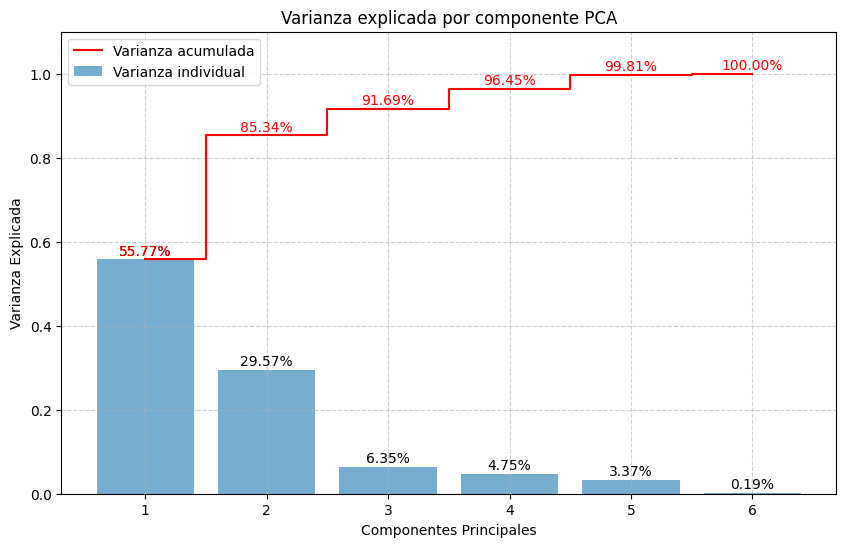

In [26]:
# Plot de Varianza Explicada y Acumulada
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.6, label='Varianza individual')
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', label='Varianza acumulada', color='red')

# Añadir valores exactos
for i, (ev, cv) in enumerate(zip(explained_variance, cumulative_variance)):
    plt.text(i + 1, ev + 0.01, f"{ev:.2%}", ha='center')
    plt.text(i + 1, cv + 0.01, f"{cv:.2%}", ha='center', color='red')

plt.xlabel('Componentes Principales')
plt.ylabel('Varianza Explicada')
plt.title('Varianza explicada por componente PCA')
plt.legend(loc='best')
plt.ylim(0, 1.1)
plt.grid(True, linestyle='--', alpha=0.6)

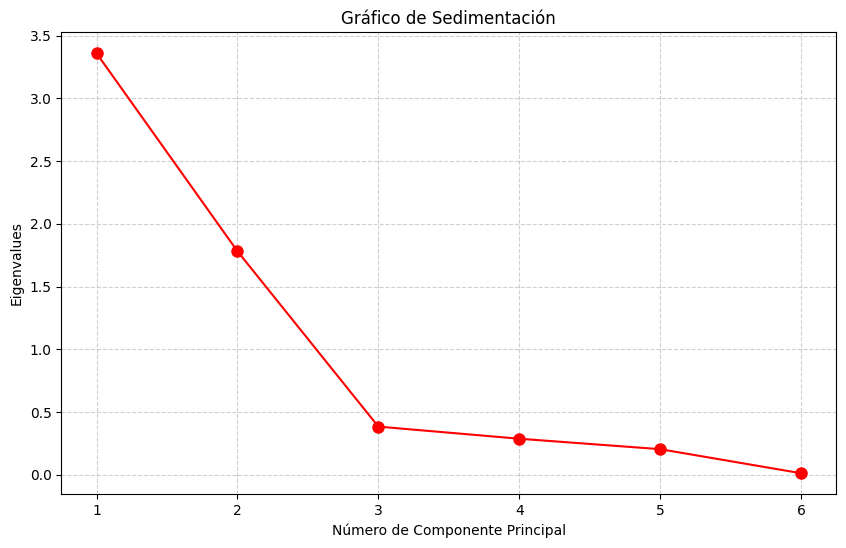

In [27]:
# Gráfico de sedimentación
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, marker='o', linestyle='-', color='r', markersize=8)

plt.title('Gráfico de Sedimentación')
plt.xlabel('Número de Componente Principal')
plt.ylabel('Eigenvalues')
plt.xticks(range(1, len(eigenvalues) + 1))
plt.grid(True, linestyle='--', alpha=0.6)